In [1]:
import numpy as np 
import cv2
import pandas as pd 
import os
import boto3
import cv2
import difflib
import gc

In [2]:
#!pip install -q keras-ocr
#from IPython.display import clear_output   
#clear_output()

In [2]:
import keras_ocr
import matplotlib.pyplot as plt

/usr/local/lib/python3.7/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/usr/local/lib/python3.7/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ["[Errno 2] The file to load file system plugin from does not exist.: '/usr/local/lib/python3.7/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so'"]
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/usr/local/lib/python3.7/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/usr/local/lib/python3.7/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/usr/local/lib/python3.7/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: cannot open shared object file: No such file or directory']
  warnings.warn(f"file system 

In [3]:
pipeline = keras_ocr.pipeline.Pipeline()

Looking for /root/.keras-ocr/craft_mlt_25k.h5
Looking for /root/.keras-ocr/crnn_kurapan.h5


In [16]:
#prueba una sola imagen
s3 = boto3.client("s3")

bucket = "cdas-2025-alertas-amber"
key = "jpg/2402_%20LimberthJosueGonzalezOrdo%C3%B1ez_AA.jpg"

response = s3.get_object(Bucket=bucket, Key=key)

image_bytes = response["Body"].read()


image_array = np.frombuffer(image_bytes, np.uint8)
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

prediction_groups = pipeline.recognize([image])

import difflib

palabras_clave = ["localizado", "localizada"]

resultados = []   # aquí guardaremos todo para luego enviarlo a PostgreSQL

for i, predictions in enumerate(prediction_groups):

    print(f"\n🖼 Imagen {i+1}")

    if len(predictions) == 0:
        print("No se detectó texto")
        continue

    # Ordenar por Y (vertical)
    pred_sorted = sorted(predictions, key=lambda x: np.mean(x[1][:, 1]))

    # Agrupar palabras en líneas
    lineas = []
    linea_actual = [pred_sorted[0]]
    y_ref = np.mean(pred_sorted[0][1][:, 1])
    tolerancia = 20

    for texto, caja in pred_sorted[1:]:
        y_prom = np.mean(caja[:, 1])

        if abs(y_prom - y_ref) < tolerancia:
            linea_actual.append((texto, caja))
        else:
            lineas.append(linea_actual)
            linea_actual = [(texto, caja)]
            y_ref = y_prom

    lineas.append(linea_actual)

    # ordenar palabras por X
    texto_final = []

    for linea in lineas:
        linea_ordenada = sorted(linea, key=lambda x: np.mean(x[1][:, 0]))
        texto_final.append(" ".join([t for t, _ in linea_ordenada]))

    texto_unido = "\n".join(texto_final)

    print("\n📄 TEXTO EXTRAÍDO:\n")
    print(texto_unido)

    # buscar palabra clave
    encontrado = False

    for palabra in palabras_clave:
        for palabra_linea in texto_unido.split():

            similitud = difflib.SequenceMatcher(
                None,
                palabra.lower(),
                palabra_linea.lower()
            ).ratio()

            if similitud >= 0.9:
                encontrado = True
                break

        if encontrado:
            break

    print("🔎 Palabra localizad@ encontrada:", "Sí" if encontrado else "No")

    # guardar resultado
    resultados.append({
        "imagen_id": i+1,
        "texto_extraido": texto_unido,
        "localizado": encontrado
    })

Looking for /root/.keras-ocr/craft_mlt_25k.h5
Looking for /root/.keras-ocr/crnn_kurapan.h5
6/6 [==============================] - 15s 2s/step

🖼 Imagen 1

📄 TEXTO EXTRAÍDO:

ecalin t ol d alerta
alerta 811zni2023 amber amber
ountans fge nco quintana roo
limberth josue
gonzalez ordonez
fecha fecha de de la los querella hechost 240212023 2210212023
edad genero 6 anos masculino
lugar solidaridad de los quintana hechosi roo playa del carmen
tez nacionalidad moreno claro mexicana
cabellor complexion corto y delgado lacio
ojost estatura color 105 cafe centimetros oscuro aprox
peso senas 24 particulares kilogramos aprox mancha en el pecho y
cicatriz en la ceja derecha
se solicita el la busqueda hechos localizacion del nino menor limberth josue
gonzalez ordonez apoyo para quien fue visto y por ltima vez en playa del carmen solidaridad
quintana retencion roo y el dia 22 sustraccion de febrero de del personas ano 2023 se menores presume de que edad o puede que ser no victima tenga del la de
fami

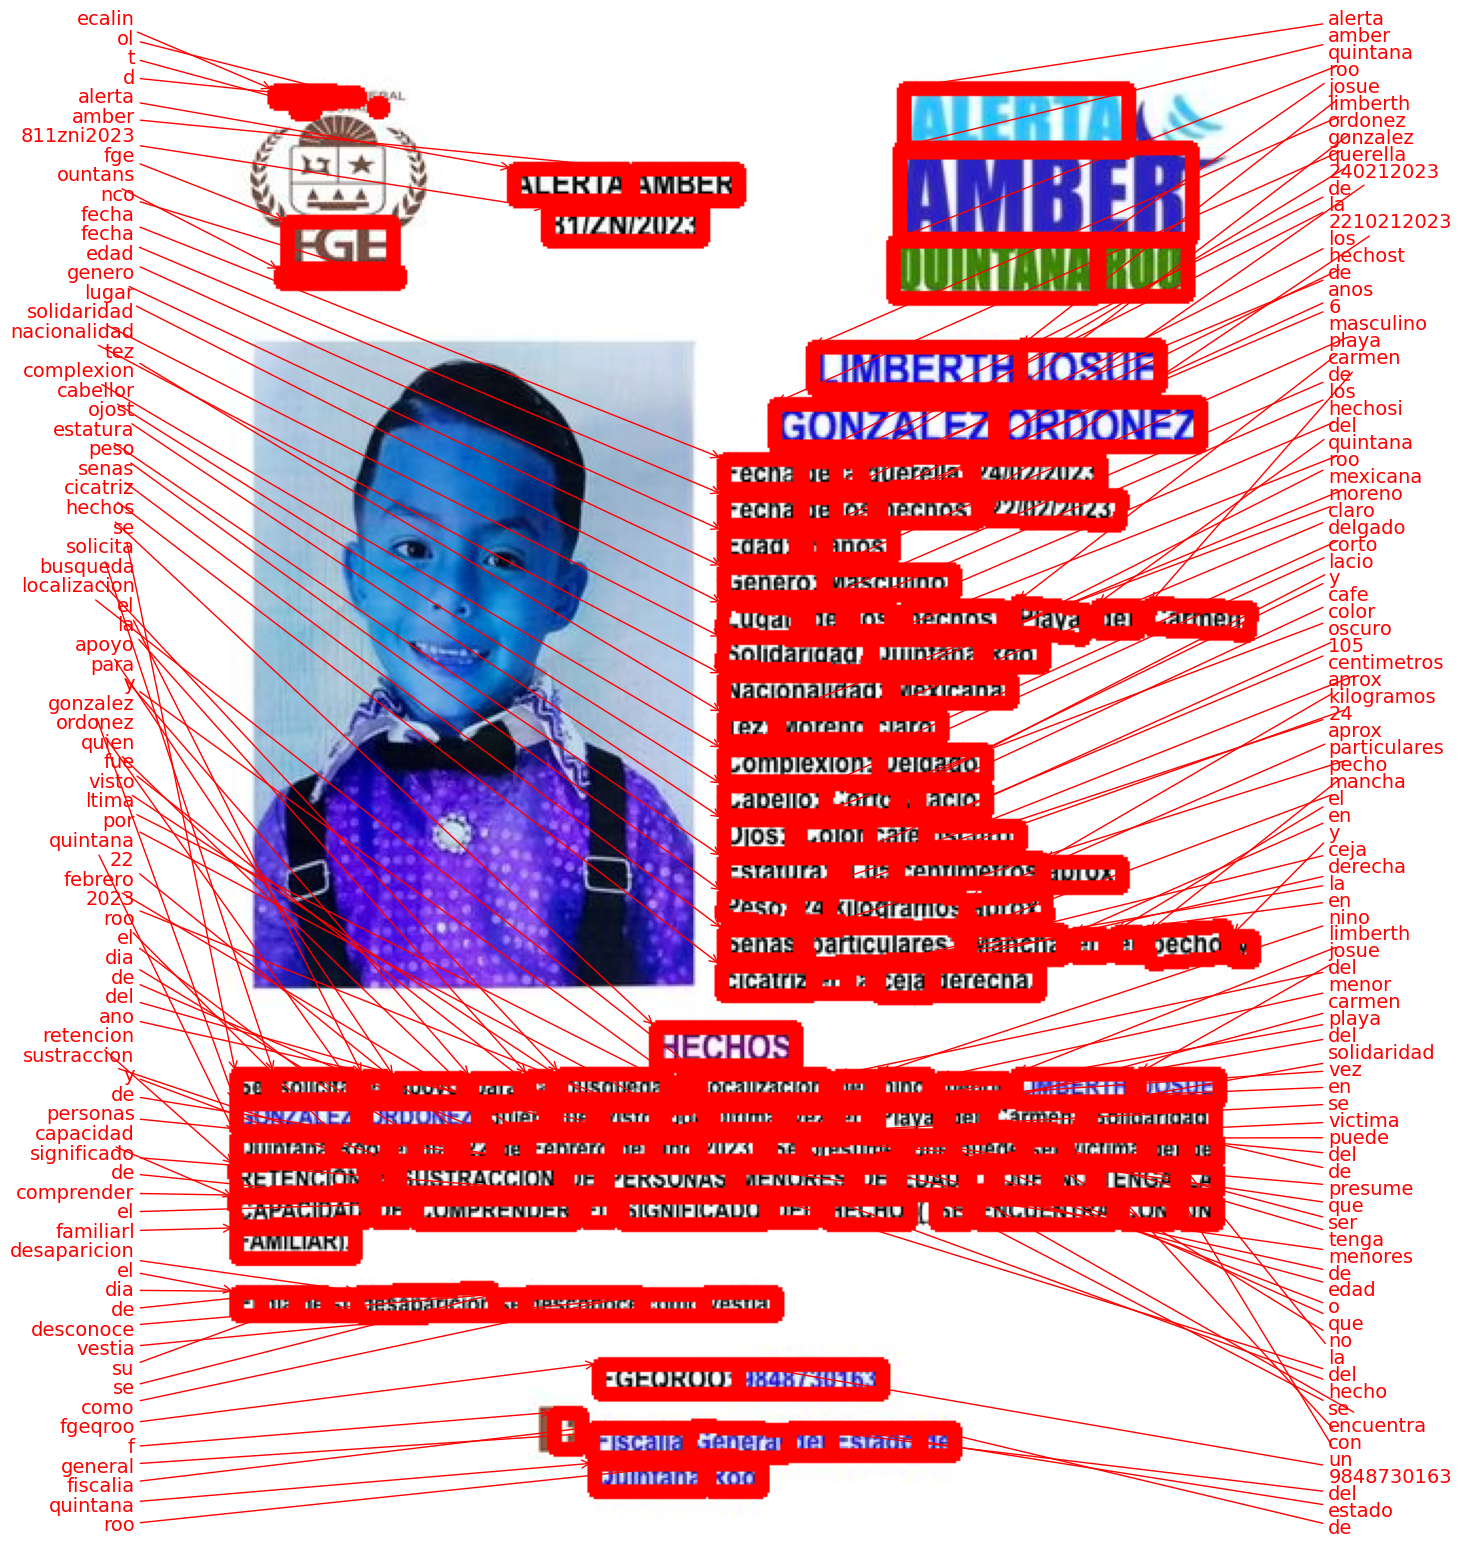

In [17]:
import matplotlib.pyplot as plt
import keras_ocr

fig, ax = plt.subplots(figsize=(14,20))

keras_ocr.tools.drawAnnotations(
    image=image,
    predictions=prediction_groups[0],
    ax=ax
)

ax.axis("off")

plt.show()

In [6]:
#prueba lote 5

In [4]:
# Obtener lista de imágenes desde S3
s3 = boto3.client("s3")

bucket = "cdas-2025-alertas-amber"
prefix = "jpg/"

keys = []

paginator = s3.get_paginator("list_objects_v2")

for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
    for obj in page.get("Contents", []):
        key = obj["Key"]
        if key.endswith(".jpg") or key.endswith(".jpeg"):
            keys.append(key)

print("Total imágenes:", len(keys))

/usr/local/lib/python3.7/site-packages/boto3/compat.py:82: PythonDeprecationWarning: Boto3 will no longer support Python 3.7 starting December 13, 2023. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.8 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


Total imágenes: 3795


In [5]:
# Función para leer imagenes de S3

def leer_imagen_s3(bucket, key):
    
    response = s3.get_object(Bucket=bucket, Key=key)
    image_bytes = response["Body"].read()
    
    image_array = np.frombuffer(image_bytes, np.uint8)
    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    
    return image

In [6]:
archivos_ya_procesados = set()
archivos_ya_procesados.add(key)

In [7]:
modo_prueba = True
limite_prueba = 5

if modo_prueba:
    keys = keys[:limite_prueba]

print("Imágenes a procesar:", len(keys))

Imágenes a procesar: 5


In [8]:
batch_size = 2
resultados = []

for i in range(0, len(keys), batch_size):

    batch_keys = keys[i:i+batch_size]

    # quitar los que ya se procesaron
    batch_keys = [k for k in batch_keys if k not in archivos_ya_procesados]

    if len(batch_keys) == 0:
        continue

    print(f"\nProcesando lote {i} - {i+len(batch_keys)}")

    images = []

    # -------------------------
    # Descargar imágenes desde S3
    # -------------------------
    for key in batch_keys:
        img = leer_imagen_s3(bucket, key)
        images.append(img)

    # -------------------------
    # OCR
    # -------------------------
    prediction_groups = pipeline.recognize(images)

    # -------------------------
    # Procesar resultados
    # -------------------------
    for key, predictions in zip(batch_keys, prediction_groups):

        palabras = [text for text, box in predictions]
        texto_unido = " ".join(palabras)

        localizado = False

        for palabra in ["localizado", "localizada"]:
            for palabra_detectada in palabras:

                similitud = difflib.SequenceMatcher(
                    None,
                    palabra.lower(),
                    palabra_detectada.lower()
                ).ratio()

                if similitud >= 0.9:
                    localizado = True
                    break

            if localizado:
                break

        resultados.append({
            "archivo_s3": key,
            "texto_extraido": texto_unido,
            "localizado": localizado
        })

        archivos_ya_procesados.add(key)

    # -------------------------
    # Liberar memoria
    # -------------------------
    del images
    del prediction_groups
    del batch_keys

    gc.collect()


Procesando lote 0 - 2


2026-03-12 07:23:43.109754: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 754974720 exceeds 10% of free system memory.
2026-03-12 07:23:43.724067: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 754974720 exceeds 10% of free system memory.
2026-03-12 07:23:44.761449: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 754974720 exceeds 10% of free system memory.
2026-03-12 07:23:46.424509: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 754974720 exceeds 10% of free system memory.
2026-03-12 07:23:46.967773: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 377487360 exceeds 10% of free system memory.


12/12 [==============================] - 30s 2s/step

Procesando lote 2 - 4
14/14 [==============================] - 39s 3s/step

Procesando lote 4 - 5
6/6 [==============================] - 15s 2s/step


In [9]:
df = pd.DataFrame(resultados)
#df.to_csv("ocr_prueba.csv", index=False)
df

,archivo_s3,texto_extraido,localizado
0,jpg/2402_%20LimberthJosueGonzalezOrdo%C3%B1ez_...,ecalin ol alerta t d amber alerta amber 811zni...,False
1,jpg/2402_%20YarisbetGuadalupeGomezHernandez_AA...,alerta amber alerta amber 65izni2023 fge quint...,True
2,jpg/2402_%20YukiradelCarmenGonzalezDzul_AA_LOC...,alerta oc tde amber alerta amber zoizni2023 fg...,True
3,jpg/2402_%20YulissaRam%C3%ADrezAlvarado_AA.jpg,ecalis clt uul alerta del tado amber alerta am...,True
4,jpg/2402_00IA3XMO1EmU7rfLtKLO.jpg,alerta cetle ol t amber nesacion cappe de fgeg...,False
